# Previsão de Atrasos em Voos — Apresentação

**Curso**: Pós-Graduação — Fase 3: Machine Learning Engineering

**Dataset**: 5.8 milhões de voos domésticos dos EUA (2015) — US Department of Transportation

## Agenda

1. O Dataset
2. Análise Exploratória — Principais Insights
3. Modelagem Supervisionada — Classificação
4. Modelagem Supervisionada — Regressão
5. Modelagem Não Supervisionada
6. Limitações e Próximos Passos
7. Conclusão

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from modules.data_loader import load_flights_clean

sns.set_style('whitegrid')
df = load_flights_clean()
print(f"Dataset limpo: {df.shape[0]:,} voos × {df.shape[1]} colunas")

Dataset limpo: 5,729,195 voos × 39 colunas


## 1. O Dataset

| Aspecto | Detalhe |
|---------|---------|
| Fonte | US Department of Transportation |
| Período | Janeiro–Dezembro 2015 |
| Registros | ~5.7 milhões de voos (após limpeza) |
| Companhias | 14 carriers |
| Aeroportos | 322+ aeroportos de origem |
| Target | `IS_DELAYED` = atraso de partida > 15 minutos |

**Imbalance**: ~82% pontuais vs ~18% atrasados

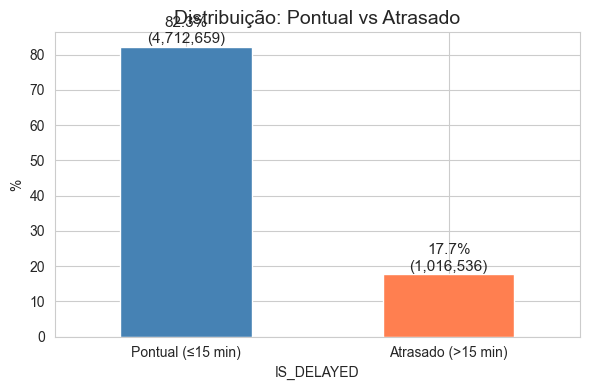

In [2]:
# Balance de classes
balance = df['IS_DELAYED'].value_counts(normalize=True) * 100
counts = df['IS_DELAYED'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
balance.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='white', ax=ax)
ax.set_title('Distribuição: Pontual vs Atrasado', fontsize=14)
ax.set_xticklabels(['Pontual (≤15 min)', 'Atrasado (>15 min)'], rotation=0)
ax.set_ylabel('%')
for i, (pct, cnt) in enumerate(zip(balance, counts)):
    ax.text(i, pct + 1, f'{pct:.1f}%\n({cnt:,})', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Principais Insights do EDA

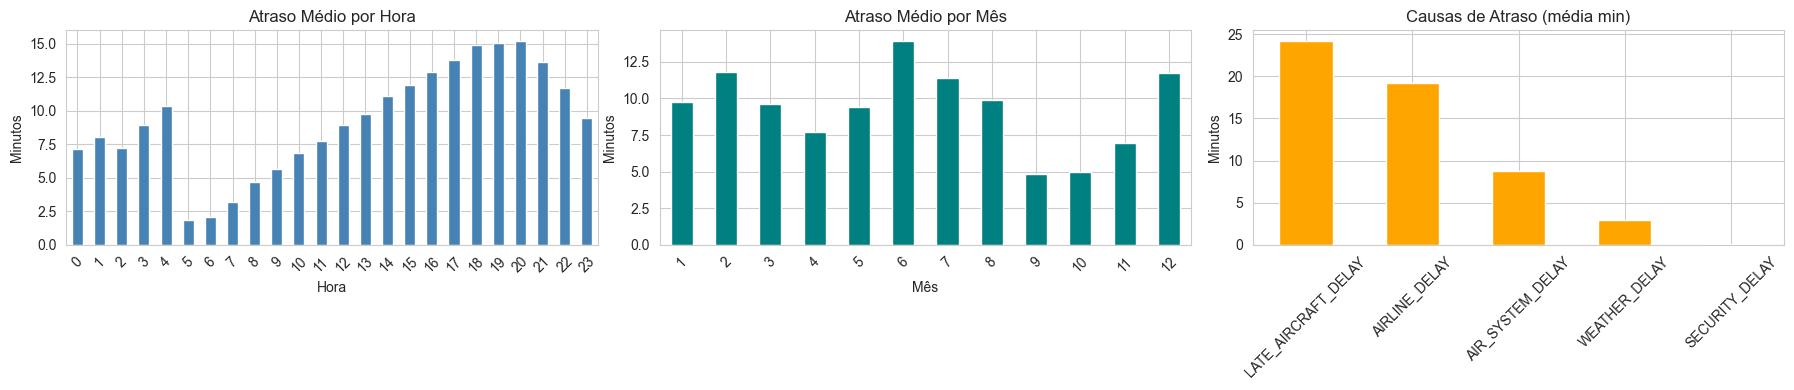

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Atraso por hora
df.groupby('DEP_HOUR')['DEPARTURE_DELAY'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Atraso Médio por Hora', fontsize=12)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Minutos')

# Atraso por mês
df.groupby('MONTH')['DEPARTURE_DELAY'].mean().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Atraso Médio por Mês', fontsize=12)
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Minutos')

# Causas de atraso
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delayed = df[df['IS_DELAYED'] == 1]
delayed[delay_cols].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='orange', edgecolor='white')
axes[2].set_title('Causas de Atraso (média min)', fontsize=12)
axes[2].set_ylabel('Minutos')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Classificação — IS_DELAYED

| Métrica | Regressão Logística | XGBoost |
|---------|-------------------|---------|
| Accuracy | *ver notebook* | *ver notebook* |
| Precision | *ver notebook* | *ver notebook* |
| Recall | *ver notebook* | *ver notebook* |
| F1-Score | *ver notebook* | *ver notebook* |
| ROC-AUC | *ver notebook* | *ver notebook* |

> **Nota**: Preencher com os resultados obtidos em `modelagem_supervisionada.ipynb`

**Observações**:
- `class_weight='balanced'` / `scale_pos_weight=4.6` para tratar imbalance 82/18
- XGBoost captura interações não-lineares entre features
- Features mais importantes: DEP_HOUR, MONTH, companhias específicas

## 4. Regressão — DEPARTURE_DELAY

| Métrica | Reg. Linear | LightGBM | XGBoost |
|---------|------------|----------|---------|
| MAE | *ver notebook* | *ver notebook* | *ver notebook* |
| RMSE | *ver notebook* | *ver notebook* | *ver notebook* |
| R² | *ver notebook* | *ver notebook* | *ver notebook* |

> **Nota**: Preencher com os resultados obtidos em `modelagem_supervisionada.ipynb`

**R² baixo é esperado** — features pré-partida (hora, dia, mês, companhia, distância) capturam padrões estatísticos gerais, mas não eventos operacionais em tempo real.

## 5. Modelagem Não Supervisionada

### PCA — Causas de Atraso
- 5 variáveis de causa → 2-3 componentes principais explicam a maior parte da variância
- LATE_AIRCRAFT_DELAY e AIRLINE_DELAY covariam (problemas operacionais)
- WEATHER_DELAY é mais independente

### K-Means — Perfis de Aeroporto
- Aeroportos agrupados por perfil operacional (atraso médio, causas, volume)
- Clusters revelam tipologia: hubs vs regionais vs aeroportos eficientes

> Detalhes completos em `modelagem_nao_supervisionada.ipynb`

## 6. Limitações

- **Temporal**: dataset de 2015 apenas — sem validação de generalização
- **Features**: apenas informações pré-partida, sem dados meteorológicos ou operacionais em tempo real
- **Imbalance**: 82/18 — modelos tendem ao viés da classe majoritária
- **Outliers**: <1% dos voos com atrasos extremos (>300 min) afetam RMSE
- **Geográfico**: ~8,3% dos aeroportos sem metadados (códigos FAA numéricos)

## 7. Próximos Passos

- Incorporar dados meteorológicos em tempo real
- Testar modelos em dados mais recentes (validação temporal)
- Feature engineering avançado (interações, embeddings)
- Deploy como API de previsão em tempo real
- Análise de anomalias (atrasos extremos)

## Conclusão

- **5 modelos** implementados: 2 classificação + 3 regressão
- **EDA completo**: padrões temporais, geográficos e por companhia identificados
- **Análise não supervisionada**: PCA revelou estrutura nas causas de atraso; K-Means identificou perfis de aeroporto
- **Achado principal**: hora do dia e companhia aérea são os preditores mais fortes de atraso
- **Limitação fundamental**: features pré-partida são insuficientes para prever magnitude exata — necessário dados em tempo real

---
*Projeto desenvolvido como parte da Pós-Graduação — Fase 3: Machine Learning Engineering*